In [1]:
import torch
import matplotlib.pyplot as plt

from bnbp5.bnn_intralayer import *
from bnbp5.trainnospikemne_intralayer_timeind_sliding_128 import Trainer
from bnbp5.mnist_spiketrain_sliding import *
import numpy as np
from os.path import exists

from zanj import ZANJ

from torch import nn

torch.set_default_dtype(torch.float32)

In [2]:
_HH_PARAMS: dict[str, float] = {
    "gna": 40.0,
    "gk": 35.0,
    "gl": 0.4, #0.3, 0.4

    "Ena": 55.0,
    "Ek": -77.0,
    "El": -60.0, #-65.0,

    "gm": 0.075,
    "ghca": 0.12, #12.0, #changed 0.12,
    "vthresh": -56.2, 
    "tau_max": 0.608,
    "Eca":  55.0, #120120.0,
    
    "gs": 0.04,
    "Vs": 0.0,
    "Iapp": 0.7,
    "lat_inhibition": False,
    "beta_n_modified": False,

    "Vt": -3.0,
    "Kp": 8.0,
    "a_d": 1.0,
    "a_r": 0.1,   
}   

# Adjust for DNN/BiLSTM/SNN
# Adjust for MNIST
CFG1: BNNConfig = BNNConfig(lr = 0.0001, neuron_model = model_HH_RS, test_batch_sz = 25, train_batch_sz = 20, neuron_params = _HH_PARAMS, model_dims = [128,100,2], dt = 1000/220/45, plot_interm=True)
    
CFG2: DatasetConfig = DatasetConfig(
            sim_t = 2000,n_samples_train=300, n_samples_val = 50, n_samples_test=9000)
    

torch.manual_seed(15)
    
trainer = Trainer(CFG1, CFG2, False,subjects=["UM_12"], ctrs1=[0,1], ctrs2=[4,5], num_classes=2)

128 100
100 2
Model parameters:
Ws.0.weight
Ws.1.weight
Loading spiketrains for phase: train, n_samples = 300, offset = 0
../data/spiketrains_train_0_300_2000_10_100.pt
Loading spiketrains for phase: validation, n_samples = 50, offset = 0
../data/spiketrains_validation_0_50_2000_10_100.pt


In [ ]:
## Measure sliding gradients

trainer.measure_sliding_gradients(10, filename = "data/meas_slid_grad_SUB012_2states_10wind") 
ZANJ().save(
        dict(
            CFG1 = CFG1,
            CFG2 = CFG2
          ),
         'data/configmeas_slid_grad_SUB012_2states_10wind',
        )

Model parameters:
Ws.0.weight
Ws.1.weight
Loading spiketrains for phase: train, n_samples = 300, offset = 0


In [4]:
sliding_grads = ZANJ().read("data/meas_slid_grad_SUB012_2states_10wind.zanj") 

changes1 = sliding_grads.get('sliding_grad_1') #[190, 78400], [150, 1] #[22, 12800])
changes2 = sliding_grads.get('sliding_grad_2') #[190, 1000], [150, 10] #[22, 200]

z1 = sliding_grads.get('interm_out')[0][0].squeeze() #[19000, 100]
a1 = sliding_grads.get('interm_out')[0][1].squeeze() #[19000, 100]
z2 = sliding_grads.get('interm_out')[1][0].squeeze() #[19000, 10]
a2 = sliding_grads.get('interm_out')[1][1].squeeze() #[19000, 10]

#w1 = torch.tensor(sliding_grads['W1s']) #[100, 784] #[150,1] 
#w2 = torch.tensor(sliding_grads['W2s']) #[10, 100], #[150,10]

## PLOTS

In [12]:
from matplotlib import font_manager as fm
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path

font_path = Path.cwd() / "data" / "font_acumin"

prop = fm.FontProperties(fname=str(font_path), size=14)
prop2 = fm.FontProperties(fname=str(font_path), size=16)

In [13]:
pwd

'c:\\Users\\yumad\\Downloads\\BNN-EEG'

In [14]:
def fig_4v4(sliding_grads, start=0, end=40, inc=10000, window_size=25, dt=0.01):
    #(start = 0, end = len(sliding_grads.get('T2_out').cpu().detach().numpy())//100, inc = 10000, window_size = 100):
    
    BNNConfig().dt = dt
    colors = ["#1B9AAA", "orange"]

    def set_ticks(ax, windowed_axis=True, inc=inc, N=end, dt=dt):
        scale = window_size if windowed_axis else 1
        inc_scaled = inc // scale
        ax.set_xticks(range(0, N + 1, inc_scaled))
        print(range(0, N + 1, inc_scaled))
        ax.set_xticklabels([f'{i * dt * scale:.0f}' for i in range(0, N + 1, inc_scaled)], fontproperties=prop)

    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()

    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1.5])  # <-- bottom row is 2× taller

    # --- 1. Output Layer Traces ---
    ax1 = fig.add_subplot(gs[0, 1])
    for i in range(2):
        color = "orange" if i == 1 else "grey"
        if i == 1:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, label=f'{i}')
        
        elif i == 9:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, alpha = 0.25, label='Others')
        else:
            ax1.plot(T2[:, i], color=color, linewidth=1.5, alpha = 0.25)
    ax1.set_title(r"$\bf{C.}$ All Output Layer Traces", fontsize=34, fontproperties=prop2)
    ax1.set_ylabel('Neuron output', fontsize=13, fontproperties=prop)
    for label in ax1.get_yticklabels():
        label.set_fontproperties(prop)

    set_ticks(ax1, windowed_axis=False, N=int(end / dt))
    ax1.set_xlim(start * 100, int(end / dt))
    #ax1.legend(["Others", "1"], fontsize=8, prop=prop, loc='lower left')

    ax2 = fig.add_subplot(gs[0, 0])
    for i in range(2):
        ax2.plot(T2[:, i], color=colors[i], linewidth=1.5, label=f'{i}')
    ax2.set_title(r"$\bf{B.}$ All Output Layer Traces", fontsize=34, fontproperties=prop2)
    ax2.set_ylabel('Neuron output', fontsize=13, fontproperties=prop)
    for label in ax2.get_yticklabels():
        label.set_fontproperties(prop)

    set_ticks(ax2, windowed_axis=False, N=int(end / dt))
    ax2.set_xlim(start * 100, int(end / dt))
    #ax2.legend(np.arange(0, 2, 1), fontsize=8, prop=prop, loc='lower left')

    # --- 3–6. Gradient plots ---
    for l, label, numbers in zip([1, 2], ['Hidden', 'Output'], [['C.', 'C.'], ['D.', 'D.']]):
        changes_key = 'sliding_grad_1' if l == 1 else 'sliding_grad_2'
        changes = sliding_grads.get(changes_key)


        # ---  Instantaneous gradients chunked line plot (your logic) ---
        ax_line = fig.add_subplot(gs[1, -l+2])

        if l == 1:
            #changes = changes[:, ::10]  # too many values otherwise
            colors = plt.cm.tab20.colors * 5
        print("CHANGES", changes.shape)
        
        if l ==2:
            colors = ["#1B9AAA", "orange"]

        changes_np = changes.cpu().numpy()
        
        numss = [1, 2]

        for i in range(numss[l-1]):
            
            num_chunks = changes_np.shape[1] // numss[l-1]
            chunk = changes_np[:, i * num_chunks:(i + 1) * num_chunks]
            offset_chunk = chunk - i * 1 * (l - 1) - i * 2 * (2 - l)
            
            print(chunk.shape)
            if l == 2:
                ax_line.plot(chunk - i * 4, color=colors[i], linewidth=0.1)
                ax_line.set_ylim(-5.5, 2.5)    
                for label in ax1.get_yticklabels():
                    label.set_fontproperties(prop)
                    
  
                # Set custom ticks and labels
                yticks = [-5, -4, -3, -2, -1, 0, 1, 2]
                ylabels = [-1, 0, 1, 2, -1, 0, 1, 2]

                ax_line.set_yticks(yticks)
                ax_line.set_yticklabels(ylabels)

                # Apply font properties
                for label in ax_line.get_yticklabels():
                    label.set_fontproperties(prop)
                #ax_line.set_yticks([])
                

                if i == 0:
                    x = np.arange(offset_chunk.shape[0])
                    y_min = -1.5#5.5
                    y_max = 2.5

                    # Fill the background in that x/y range
                    ax_line.fill_between(x, y_min, y_max, color='lightgray', alpha=0.4)
            if l == 1:
                print("chunk",chunk.shape, np.min(chunk), np.max(chunk))
                for mm in range(100):
                    ax_line.plot(chunk[:, mm*128:(mm+1)*128], color=colors[mm])#,linewidth=0.05)
                #ax_line.set_ylim(20-40*1, 20)
                
                 # Set custom ticks and labels
                #yticks = [-15, -5, 5, 15]
                #ylabels = [-15, -5, 5, 15]

                #ax_line.set_yticks(yticks)
                #ax_line.set_yticklabels(ylabels)

                # Apply font properties
                for label in ax_line.get_yticklabels():
                    label.set_fontproperties(prop)
                #ax_line.set_yticks([])
                
                
                if i == 0:
                    x = np.arange(offset_chunk.shape[0])
                    y_min = 20
                    y_max = -20

                    # Fill the background in that x/y range
                    #ax_line.fill_between(x, y_min, y_max, color='lightgray', alpha=0.4)
                
                
        #set_ticks(ax_line)#r"$\bf{A.}$ All Output Layer Traces"
        set_ticks(ax_line, windowed_axis=True, N=int(end / dt// window_size))
        print("sizes", start // dt // window_size, end // dt // window_size)
        
        ax_line.set_title(rf'$\bf{{{numbers[0]}}}$ {label} Instantaneous Gradients', fontproperties=prop2)
        ax_line.set_ylabel('Gradient (flattened)', fontsize=14, fontproperties=prop)
        ax_line.set_xlim(start // dt // window_size, end // dt // window_size)

    # Shared x labels
    fig.text(0.25, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)

    plt.tight_layout()
    plt.show()

    BNNConfig().sim_t = 4000

range(0, 2011, 1000)
range(0, 2011, 1000)
CHANGES torch.Size([220, 12800])
(220, 12800)
chunk (220, 12800) -22.67007 20.807636
range(0, 202, 100)
sizes 0.0 200.0
CHANGES torch.Size([220, 200])
(220, 100)
(220, 100)
range(0, 202, 100)
sizes 0.0 200.0


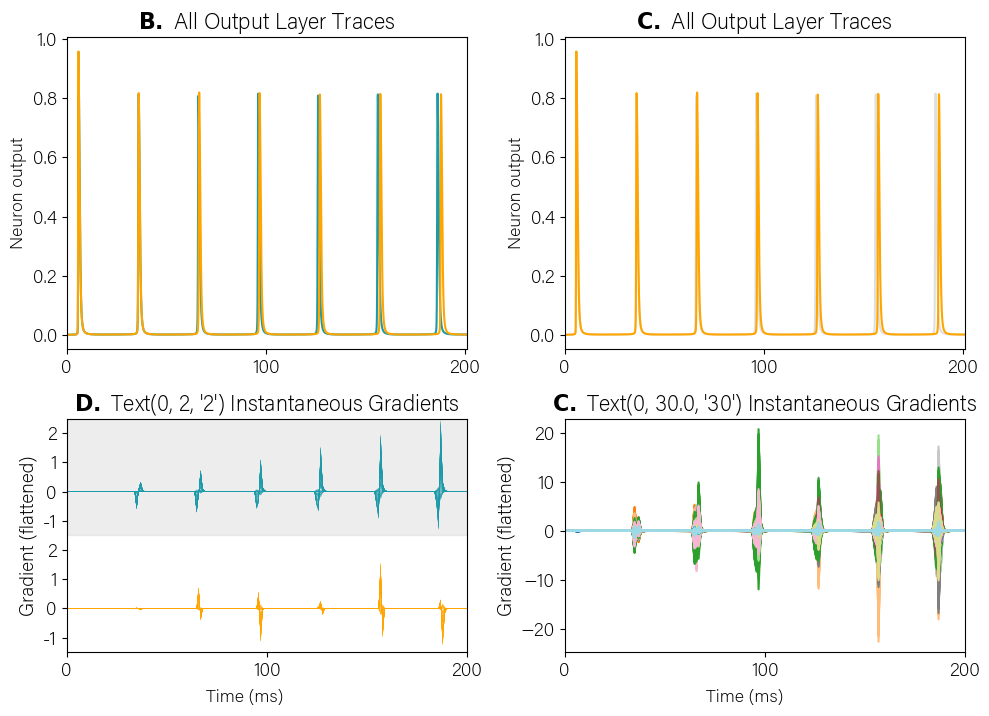

In [15]:
fig_4v4(sliding_grads,start = 0, end = 201, inc = 1000, window_size = 10, dt = 0.1)

In [ ]:
def fig_4v5(sliding_grads, start = 0, end = 40, inc = 10000, window_size = 25, dt = 0.1):
    ## Zoomed in version of gradient

    BNNConfig().dt = 0.1#05
    window_size = window_size
 
    colors = ["#1B9AAA", "orange"]

    
    def set_ticks(windowed_axis = True, inc = inc, N = end, dt = dt):
        
       # print(" ..", windowed_size)
        scale = window_size if windowed_axis else 1
        inc = inc // scale
        if windowed_axis == True:
            print("pr", "inc", inc, N,dt, scale, [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)])
        plt.xticks(range(0,N+1,inc), [f'{i*dt*scale:.0f}' for i in range(0,N+1,inc)], fontproperties=prop)
 
    T2 = sliding_grads.get('T2_out').cpu().detach().numpy()
    fig = plt.figure(figsize = (5, 2))          
    

    for l, label, numbers in zip([1,2], ['Hidden', 'Output'], [['D.', 'F.'], ['D.', 'F.']]):
        plot_idx = 5 if l == 1 else 3 
        changes_key = 'sliding_grad_1' if l == 1 else 'sliding_grad_2'
        changes = sliding_grads.get(changes_key)

        
        if l == 2:
            # Convert to numpy
            changes_np = changes.cpu().numpy()

            # Number of chunks
            num_chunks = changes_np.shape[1] // 10
                       
            for i in range(10):
                # Extract each chunk
                chunk = changes_np[:, i*num_chunks:(i+1)*num_chunks]

                if l==2 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
                
               #     plt.ylim(-10,1)
               #     plt.yticks([])    
                if l==1 and i == 1:
                    plt.plot(chunk - i*1*(l-1) - i*200*(2-l), color = colors[i], linewidth=0.9)
               # 
               #     plt.ylim(-1900,200)
               #     plt.yticks([])    
                

        set_ticks(windowed_axis=True, N=int(end / dt// window_size))
        #plt.title(f'{numbers[0]} {label} Correct Neuron Instantaneous Gradients', fontproperties=prop2)
        plt.ylabel('Gradient (flattened)', fontsize = 14, fontproperties=prop)
       # plt.axvspan(210, 240, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
       # plt.axvspan(110, 150, edgecolor=hi_color, linestyle='--', linewidth=hi_width, facecolor='none')
        plt.xlim(start//dt//window_size, end//dt//window_size)
        plt.yticks( fontproperties=prop) 

      
    fig.text(0.5, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    #fig.text(0.75, -0.01, 'Time (ms)', ha='center', fontsize=13, fontproperties=prop)
    plt.tight_layout()
    
    
    #plt.savefig('../figures/fig_4_changes.pdf')
    plt.show()
    BNNConfig().sim_t = 4000
   

pr inc 1000 210 0.01 10 ['0']
pr inc 1000 210 0.01 10 ['0']


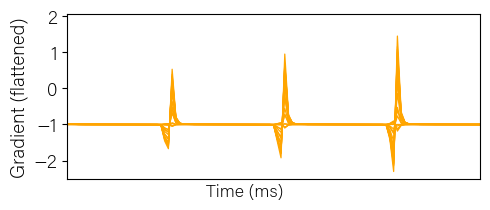

In [17]:
fig_4v5(sliding_grads,start = 10, end = 21, inc = 10000, window_size = 10, dt = 0.01)